In [ ]:
import importlib.util, subprocess, sys

required = ["pandas", "numpy", "scipy", "matplotlib", "seaborn", "yaml", "statsmodels"]
pip_names = {"yaml": "pyyaml"}
missing = [pip_names.get(m, m) for m in required if importlib.util.find_spec(m) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print(f"installed missing packages: {missing}")
else:
    print("packages ready (no upgrade attempted)")

✓ packages ready (no upgrade attempted)


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✓ Google Drive mounted")
except ImportError:
    print("Not running in Colab — Drive mount skipped")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted


In [ ]:
import subprocess, sys
from pathlib import Path

REPO_DIR = Path("/content/finn")
if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/must1f/finn.git", str(REPO_DIR)],
        check=True,
    )
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)], check=True)
print("src package installed")

✓ src package installed


In [ ]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

_LOCAL_WF  = Path("results/walk_forward")
_DRIVE_WF  = Path("/content/drive/MyDrive/finn_results/walk_forward")
WF_BASE_DIR: Path = _LOCAL_WF if _LOCAL_WF.exists() else _DRIVE_WF
print(f"Walk-forward root: {WF_BASE_DIR}")


def _resolve_model_dir(base_dir, model_name):
    """Locate the directory holding fold_* subdirs for model_name."""
    candidates = [base_dir / model_name]
    if model_name.endswith("_tuned"):
        candidates.append(base_dir / "tuned" / model_name.removesuffix("_tuned"))
    for d in candidates:
        if d.exists() and any(d.glob("fold_*")):
            return d
    return None


def _candidate_pred_paths(base_dir, model_name):
    """Return ordered candidate wf_preds.json locations.

    Tuned PINN variants are written by emit_wf_artefacts_pinn to
    <base>/tuned/<base_name>/ (the registry suffix _tuned is dropped).
    """
    candidates = [base_dir / model_name / "wf_preds.json"]
    if model_name.endswith("_tuned"):
        base_name = model_name.removesuffix("_tuned")
        candidates.append(base_dir / "tuned" / base_name / "wf_preds.json")
    return candidates


def _per_fold_lengths(base_dir, model_name):
    """Return per-fold test-window lengths read from fold_*/seed_*/*.json."""
    md = _resolve_model_dir(base_dir, model_name)
    if md is None:
        return []
    base_name = model_name.removesuffix("_tuned") if model_name.endswith("_tuned") else model_name
    lens = []
    for f in sorted(md.glob("fold_*"), key=lambda p: int(p.name.split("_")[1])):
        seed_jsons = sorted(f.glob(f"seed_*/{model_name}_result.json"))
        if not seed_jsons and model_name.endswith("_tuned"):
            seed_jsons = sorted(f.glob(f"seed_*/{base_name}_result.json"))
        if not seed_jsons:
            seed_jsons = sorted(f.glob("seed_*/*.json"))
        if not seed_jsons:
            continue
        d = json.loads(seed_jsons[0].read_text())
        if d.get("test_actual"):
            lens.append(len(d["test_actual"]))
    return lens


def _per_fold_tail_trim(arr, fold_lens, canonical_lens):
    if list(fold_lens) == list(canonical_lens):
        return arr
    out = []
    cursor = 0
    for L, C in zip(fold_lens, canonical_lens):
        seg = arr[cursor: cursor + L]
        if C > L:
            raise ValueError(f"canonical fold len {C} exceeds source fold len {L}")
        out.append(seg[-C:])
        cursor += L
    return np.concatenate(out)


def _load_preds(base_dir, model_name):
    for preds_file in _candidate_pred_paths(base_dir, model_name):
        if preds_file.exists():
            d = json.loads(preds_file.read_text())
            p, a = d.get("test_preds"), d.get("test_actual")
            if p and a:
                return np.array(p, dtype=float), np.array(a, dtype=float)

    base_name = model_name.removesuffix("_tuned") if model_name.endswith("_tuned") else model_name
    for model_dir in [
        base_dir / model_name,
        base_dir / "tuned" / base_name if model_name.endswith("_tuned") else None,
    ]:
        if model_dir is None or not model_dir.exists():
            continue
        fold_dirs = sorted(model_dir.glob("fold_*"), key=lambda p: int(p.name.split("_")[1]))
        all_p, all_a = [], []
        for fd in fold_dirs:
            result_jsons = sorted(fd.glob(f"seed_*/{model_name}_result.json"))
            if not result_jsons and model_name.endswith("_tuned"):
                result_jsons = sorted(fd.glob(f"seed_*/{base_name}_result.json"))
            if not result_jsons:
                continue
            d = json.loads(result_jsons[0].read_text())
            if d.get("test_preds") and d.get("test_actual"):
                all_p.extend(d["test_preds"])
                all_a.extend(d["test_actual"])
        if all_p:
            return np.array(all_p, dtype=float), np.array(all_a, dtype=float)
    return None, None


def dm_test(preds_a, preds_b, actual, h=1):
    """Two-sided Diebold-Mariano with Harvey 1997 small-sample correction.

    d_t = e_a^2 - e_b^2 where e = actual - preds. Positive stat => B has lower MSE.
    For h=1, variance reduces to sample var; for h>1, NW with lag h-1.

    Args:
        preds_a, preds_b: 1-D log-return predictions, shape (T,).
        actual: 1-D ground-truth log returns, shape (T,).
        h: forecast horizon.

    Returns:
        (dm_stat, p_value) two-sided under t(T-1).
    """
    T = len(actual)
    if T < 3:
        return float("nan"), float("nan")
    e_a = actual - preds_a
    e_b = actual - preds_b
    d   = e_a ** 2 - e_b ** 2
    d_bar = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    nw_var = gamma0
    for lag in range(1, h):
        gamma_l = np.cov(d[lag:], d[:-lag])[0, 1]
        nw_var += 2 * (1 - lag / h) * gamma_l
    nw_var = max(nw_var, 1e-15)
    dm_stat = d_bar / np.sqrt(nw_var / T)
    correction = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_stat_adj = dm_stat * correction
    p_val = 2.0 * stats.t.sf(abs(dm_stat_adj), df=T - 1)
    return float(dm_stat_adj), float(p_val)


def directional_accuracy(p, a, drop_ties=True):
    """Sign-match DA on log-returns.

    Args:
        p, a: 1-D arrays.
        drop_ties: drop rows where either p or a is exactly zero.

    Returns:
        (da, n_correct, n_eff).
    """
    sp, sa = np.sign(p), np.sign(a)
    if drop_ties:
        mask = (sp != 0) & (sa != 0)
    else:
        mask = np.ones_like(sp, dtype=bool)
    n_eff = int(mask.sum())
    if n_eff == 0:
        return float("nan"), 0, 0
    n_correct = int(np.sum(sp[mask] == sa[mask]))
    return n_correct / n_eff, n_correct, n_eff


def sig_stars(p):
    if np.isnan(p): return "  "
    return "***" if p < 0.001 else "** " if p < 0.01 else "*  " if p < 0.05 else "ns "



PRETTY_LABELS = {
    "random_walk":               "Random Walk",
    "historical_mean":           "Historical Mean",
    "persistence":               "Persistence",
    "garch":                     "GARCH",
    "lstm":                      "LSTM",
    "gru":                       "GRU",
    "bilstm":                    "BiLSTM",
    "attention_lstm":            "Attention\u2013LSTM",
    "transformer":               "Transformer",
    "baseline_pinn":             "Baseline PINN",
    "gbm_pinn":                  "GBM\u2013PINN",
    "gbm_pinn_tuned":            "GBM\u2013PINN (Tuned)",
    "ou_pinn":                   "OU\u2013PINN",
    "ou_pinn_tuned":             "OU\u2013PINN (Tuned)",
    "bs_pinn":                   "BS\u2013PINN",
    "bs_pinn_tuned":             "BS\u2013PINN (Tuned)",
    "global_pinn":               "Global PINN",
    "global_pinn_tuned":         "Global PINN (Tuned)",
    "hawkes_pinn":               "Hawkes PINN",
    "hawkes_pinn_tuned":         "Hawkes PINN (Tuned)",
    "hawkes_ou_pinn":            "Hawkes\u2013OU PINN",
    "stacked_pinn":              "Stacked PINN",
    "stacked_pinn_tuned":        "Stacked PINN (Tuned)",
    "residual_pinn":             "Residual PINN",
    "residual_pinn_tuned":       "Residual PINN (Tuned)",
    "hawkes_v2_pinn":            "Hawkes-v2 PINN",
    "hawkes_v2_pinn_tuned":      "Hawkes-v2 PINN (Tuned)",
    "hawkes_v2_multiscale_pinn": "Hawkes-v2 Multiscale PINN",
}


def pretty(name):
    if name in PRETTY_LABELS:
        return PRETTY_LABELS[name]
    return name.replace("_", " ").title()


print("\u2713 DM helpers loaded")


Walk-forward root: /content/drive/MyDrive/finn_results/walk_forward
✓ DM helpers loaded


In [ ]:
ALL_MODELS = [
    "random_walk", "historical_mean", "persistence", "garch",
    "lstm", "gru", "bilstm", "attention_lstm", "transformer",
    "baseline_pinn", "gbm_pinn", "ou_pinn", "gbm_pinn_tuned", "ou_pinn_tuned",
    "bs_pinn", "global_pinn", "bs_pinn_tuned", "global_pinn_tuned",
    "hawkes_pinn", "hawkes_pinn_tuned", "hawkes_ou_pinn",
    "stacked_pinn", "stacked_pinn_tuned", "residual_pinn", "residual_pinn_tuned",
    "hawkes_v2_pinn", "hawkes_v2_multiscale_pinn", "hawkes_v2_pinn_tuned",
]

preds_store    = {}
actual_store   = {}
fold_lens_store = {}

for model in ALL_MODELS:
    p, a = _load_preds(WF_BASE_DIR, model)
    if p is None:
        print(f"{model:<40}  NOT FOUND")
        continue
    preds_store[model]  = p
    actual_store[model] = a
    fold_lens_store[model] = _per_fold_lengths(WF_BASE_DIR, model)
    fl_str = "+".join(map(str, fold_lens_store[model])) if fold_lens_store[model] else "?"
    print(f"{model:<40}  T={len(p):4}  folds=[{fl_str}]")

print(f"\n{len(preds_store)}/{len(ALL_MODELS)} models loaded")


In [ ]:
loaded = list(preds_store.keys())
fold_lens = {m: fold_lens_store[m] for m in loaded if fold_lens_store[m]}

if not fold_lens:
    raise RuntimeError("No per-fold metadata recovered; cannot verify alignment.")

n_folds = max(len(v) for v in fold_lens.values())
if any(len(v) != n_folds for v in fold_lens.values()):
    bad = {m: v for m, v in fold_lens.items() if len(v) != n_folds}
    raise RuntimeError(f"Models disagree on fold count (expected {n_folds}). Offenders: {bad}")
canonical_lens = [min(fold_lens[m][k] for m in fold_lens) for k in range(n_folds)]
T_canon = sum(canonical_lens)
print(f"Canonical per-fold test lengths: {canonical_lens}  (T={T_canon})")

trim_log = []
for m in list(preds_store.keys()):
    if m not in fold_lens:
        if len(preds_store[m]) != T_canon:
            preds_store[m]  = preds_store[m][-T_canon:]
            actual_store[m] = actual_store[m][-T_canon:]
            trim_log.append(f"{m}: global tail-trim to T={T_canon}")
        continue
    src_lens = fold_lens[m]
    if list(src_lens) != list(canonical_lens):
        preds_store[m]  = _per_fold_tail_trim(preds_store[m],  src_lens, canonical_lens)
        actual_store[m] = _per_fold_tail_trim(actual_store[m], src_lens, canonical_lens)
        trim_log.append(f"{m}: per-fold trim {src_lens} -> {canonical_lens}")
if trim_log:
    print("Trimmed:")
    for line in trim_log: print(f"  • {line}")
else:
    print("All models already share the canonical fold structure.")

_reference = "random_walk" if "random_walk" in actual_store else loaded[0]
ACTUAL = actual_store[_reference]
assert len(ACTUAL) == T_canon, f"reference actuals len {len(ACTUAL)} != T_canon {T_canon}"

_misaligned = []
for m, a in actual_store.items():
    if not np.allclose(a, ACTUAL, atol=1e-10, equal_nan=False):
        _misaligned.append(m)
if _misaligned:
    raise RuntimeError(
        "Cross-model actuals mismatch after per-fold trim — fold END dates "
        f"likely differ. Offenders (vs {_reference}): {_misaligned}. "
        "Rerun the offending WF notebooks with the shared "
        "walk_forward.test_years config before continuing."
    )
print(f"Actuals sourced from '{_reference}', length {len(ACTUAL)}")
print(f"All {len(actual_store)} models share the same per-fold-trimmed actuals (atol=1e-10)")


In [ ]:
from statsmodels.stats.multitest import multipletests

models = sorted(preds_store.keys())
N = len(models)
dm_stats = np.full((N, N), np.nan)
dm_pvals = np.full((N, N), np.nan)

for i, m_a in enumerate(models):
    for j, m_b in enumerate(models):
        if i == j:
            continue
        dm_s, dm_p = dm_test(preds_store[m_a], preds_store[m_b], ACTUAL)
        dm_stats[i, j] = dm_s
        dm_pvals[i, j] = dm_p


_off_diag = ~np.eye(N, dtype=bool)
_flat_p = dm_pvals[_off_diag]
_reject, _padj, _, _ = multipletests(_flat_p, alpha=0.05, method="fdr_bh")
dm_pvals_adj = np.full_like(dm_pvals, np.nan)
dm_pvals_adj[_off_diag] = _padj

dm_df       = pd.DataFrame(dm_stats,     index=models, columns=models)
pval_df     = pd.DataFrame(dm_pvals,     index=models, columns=models)
pval_adj_df = pd.DataFrame(dm_pvals_adj, index=models, columns=models)
print("DM statistic matrix (positive = column model is better):")
print(dm_df.round(3).to_string())
print(f"\nBH-FDR adjustment applied across {int(_off_diag.sum())} pairwise tests.")
print(f"  raw p<0.05    rejections: {int(np.sum(_flat_p < 0.05))}")
print(f"  BH-adj p<0.05 rejections: {int(np.sum(_padj < 0.05))}")


DM statistic matrix (positive = column model is better):
                           attention_lstm  baseline_pinn  bilstm  bs_pinn  bs_pinn_tuned   garch  gbm_pinn  gbm_pinn_tuned  global_pinn  global_pinn_tuned     gru  hawkes_ou_pinn  hawkes_pinn  hawkes_pinn_tuned  hawkes_v2_multiscale_pinn  hawkes_v2_pinn  hawkes_v2_pinn_tuned  historical_mean    lstm  ou_pinn  ou_pinn_tuned  persistence  random_walk  residual_pinn  residual_pinn_tuned  stacked_pinn  stacked_pinn_tuned  transformer
attention_lstm                        NaN          6.696   5.083    6.701          5.426   6.749     5.423           5.400        6.712              5.490   4.826           2.880        2.669              2.669                      1.349          -2.061                -2.061            6.706   5.164    5.427          5.401       -3.942        6.628          6.044                5.927         0.832               0.505       -2.405
baseline_pinn                      -6.696            NaN  -3.400    1.603  

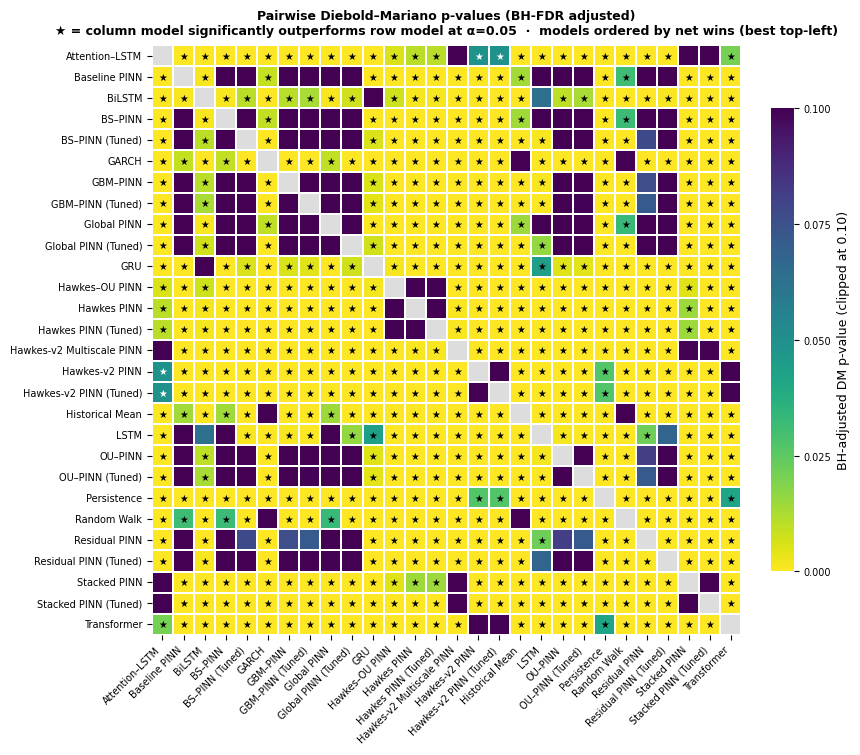

✓ Saved results/final_dm/dm_pvalue_heatmap.{pdf,eps,png}  + dm_{stats,pvalues_raw,pvalues_bh,pvalues_bh_ordered}.csv


In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

_pub_rc = {
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":        8,
    "axes.labelsize":   9,
    "axes.titlesize":   10,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.6,
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
    "savefig.dpi":      600,
    "savefig.bbox":     "tight",
}


_alpha = 0.05
_net = np.zeros(N)
for i in range(N):
    for j in range(N):
        if i == j or np.isnan(dm_pvals_adj[i, j]):
            continue
        if dm_pvals_adj[i, j] < _alpha:

            _net[j] += 1
            _net[i] -= 1
order = np.argsort(-_net)                      
models_ord       = [models[k]         for k in order]
models_ord_disp  = [pretty(m)         for m in models_ord]
P = dm_pvals_adj[np.ix_(order, order)]

with mpl.rc_context(_pub_rc):

    side_in = 8.5
    fig, ax = plt.subplots(figsize=(side_in, side_in), constrained_layout=True)

    diag_mask = np.eye(N, dtype=bool)
    cmap = plt.get_cmap("viridis_r").copy()
    cmap.set_bad("#dddddd")                     
    norm = mpl.colors.Normalize(vmin=0.0, vmax=0.10)

    sns.heatmap(
        P,
        mask=diag_mask,
        annot=False,
        cmap=cmap, norm=norm,
        linewidths=0.3, linecolor="white",
        square=True,
        xticklabels=models_ord_disp, yticklabels=models_ord_disp,
        ax=ax,
        cbar_kws={
            "label":  "BH-adjusted DM p-value (clipped at 0.10)",
            "shrink": 0.55,
            "ticks":  [0.0, 0.025, 0.05, 0.075, 0.10],
        },
    )


    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            p = P[i, j]
            if np.isnan(p) or p >= _alpha:
                continue
            rgba = cmap(norm(p))
            lum = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
            ax.text(j + 0.5, i + 0.5, "★",
                    ha="center", va="center",
                    fontsize=7,
                    color=("white" if lum < 0.5 else "black"))

    ax.set_title(
        "Pairwise Diebold–Mariano p-values (BH-FDR adjusted)\n"
        "★ = column model significantly outperforms row model at α=0.05  ·  "
        "models ordered by net wins (best top-left)",
        fontsize=9, fontweight="bold", pad=8,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    for lbl in ax.get_xticklabels():
        lbl.set_horizontalalignment("right")
    sns.despine(ax=ax, left=True, bottom=True)

    out_dir = Path("results/final_dm")
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "dm_pvalue_heatmap.pdf", facecolor="white")
    fig.savefig(out_dir / "dm_pvalue_heatmap.eps", facecolor="white")
    fig.savefig(out_dir / "dm_pvalue_heatmap.png", dpi=600, facecolor="white")
    display(fig)
    plt.close(fig)

# Persist ordered + raw matrices for downstream tables. CSVs keep raw snake_case
# keys so they remain machine-readable; the figure is the human-facing artefact.
pval_df.to_csv(out_dir / "dm_pvalues_raw.csv")
pval_adj_df.to_csv(out_dir / "dm_pvalues_bh.csv")
dm_df.to_csv(out_dir / "dm_stats.csv")
pd.DataFrame(P, index=models_ord, columns=models_ord)\
    .to_csv(out_dir / "dm_pvalues_bh_ordered.csv")
print(f"✓ Saved {out_dir}/dm_pvalue_heatmap.{{pdf,eps,png}}  + dm_{{stats,pvalues_raw,pvalues_bh,pvalues_bh_ordered}}.csv")


In [ ]:
PINN_MODELS = [
    "baseline_pinn",
    "gbm_pinn", "gbm_pinn_tuned",
    "ou_pinn",  "ou_pinn_tuned",
    "bs_pinn",  "bs_pinn_tuned",
    "global_pinn", "global_pinn_tuned",
    "hawkes_pinn", "hawkes_pinn_tuned", "hawkes_ou_pinn",
    "stacked_pinn", "stacked_pinn_tuned",
    "residual_pinn", "residual_pinn_tuned",
    "hawkes_v2_pinn", "hawkes_v2_multiscale_pinn", "hawkes_v2_pinn_tuned",
]
BENCHMARKS = ["random_walk", "baseline_pinn"]

rows = []
for pinn in PINN_MODELS:
    if pinn not in preds_store:
        continue
    row = {"model": pinn}
    rmse_pinn = float(np.sqrt(np.mean((ACTUAL - preds_store[pinn]) ** 2)))
    row["rmse"] = rmse_pinn
    da_pinn, _, n_eff = directional_accuracy(preds_store[pinn], ACTUAL, drop_ties=True)
    row["da"]    = round(da_pinn, 4) if not np.isnan(da_pinn) else float("nan")
    row["n_eff"] = n_eff
    for bm in BENCHMARKS:
        if bm not in preds_store:
            row[f"dm_vs_{bm}"] = float("nan")
            row[f"p_vs_{bm}"]  = float("nan")
            continue
        s, p = dm_test(preds_store[pinn], preds_store[bm], ACTUAL)
        row[f"dm_vs_{bm}"] = round(s, 3)
        row[f"p_vs_{bm}"]  = round(p, 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("model")
print("\n=== PINN vs benchmark DM table (raw p-values) ===")
print(summary_df.to_string())
summary_df.to_csv(out_dir / "pinn_vs_benchmark_dm.csv")
print(f"\nSaved {out_dir}/pinn_vs_benchmark_dm.csv")
print("Interpretation: dm_vs_X > 0  =>  benchmark X has lower MSE (PINN is worse).")
print("                p_vs_X < 0.05 (raw) does NOT account for multiple testing;")
print("                see dm_pvalues_bh.csv for the BH-FDR-adjusted matrix.")



=== PINN vs benchmark DM table (raw p-values) ===
                               rmse      da  n_eff  dm_vs_random_walk  p_vs_random_walk  dm_vs_baseline_pinn  p_vs_baseline_pinn
model                                                                                                                           
baseline_pinn              0.011322  0.4909   1149              2.254            0.0244                0.000              1.0000
gbm_pinn                   0.011466  0.4743   1149              4.069            0.0001                1.144              0.2527
gbm_pinn_tuned             0.011472  0.4813   1149              3.924            0.0001                1.206              0.2280
ou_pinn                    0.011462  0.4656   1149              4.102            0.0000                1.106              0.2687
ou_pinn_tuned              0.011471  0.4813   1149              3.923            0.0001                1.205              0.2286
bs_pinn                    0.011320  0.4943   

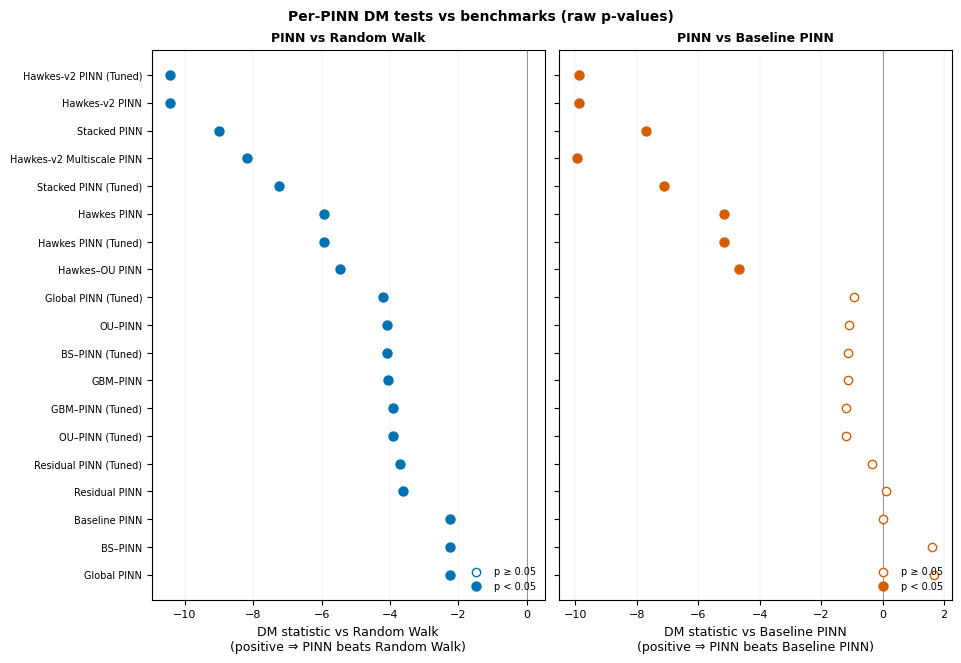

✓ Saved results/final_dm/pinn_vs_benchmark_forest.{pdf,png}


In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 9, "axes.titlesize": 10,
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.bbox": "tight",
}

with mpl.rc_context(_pub_rc):
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 0.28 * len(summary_df) + 1.2),
                             sharey=True, constrained_layout=True)
    bench_colors = {"random_walk": "#0072B2", "baseline_pinn": "#D55E00"}

    order = summary_df.sort_values("dm_vs_random_walk", ascending=True).index.tolist()
    order_disp = [pretty(m) for m in order]
    y = np.arange(len(order))

    for ax, bm in zip(axes, BENCHMARKS):
        dm   = -summary_df.loc[order, f"dm_vs_{bm}"].values
        pval =  summary_df.loc[order, f"p_vs_{bm}"].values
        sig  = pval < 0.05
        c    = bench_colors[bm]
        bm_disp = pretty(bm)

        ax.axvline(0, color="grey", lw=0.6, zorder=0)
        ax.scatter(dm[~sig], y[~sig], facecolors="white", edgecolors=c,
                   s=36, lw=1.0, label="p ≥ 0.05", zorder=2)
        ax.scatter(dm[sig],  y[sig],  facecolors=c, edgecolors=c,
                   s=42, lw=1.0, label="p < 0.05", zorder=3)

        ax.set_yticks(y); ax.set_yticklabels(order_disp, fontsize=7)
        ax.set_xlabel(f"DM statistic vs {bm_disp}\n(positive ⇒ PINN beats {bm_disp})")
        ax.set_title(f"PINN vs {bm_disp}", fontsize=9, fontweight="bold")
        ax.grid(axis="x", lw=0.3, alpha=0.4)
        ax.legend(loc="lower right", frameon=False, fontsize=7)

    fig.suptitle("Per-PINN DM tests vs benchmarks (raw p-values)",
                 fontsize=10, fontweight="bold")
    fig.savefig(out_dir / "pinn_vs_benchmark_forest.pdf", facecolor="white")
    fig.savefig(out_dir / "pinn_vs_benchmark_forest.png", dpi=300, facecolor="white")
    display(fig); plt.close(fig)
print(f"Saved {out_dir}/pinn_vs_benchmark_forest.{{pdf,png}}")


In [ ]:
wins  = {m: 0 for m in models}
losses = {m: 0 for m in models}
for i, m_a in enumerate(models):
    for j, m_b in enumerate(models):
        if i == j or np.isnan(dm_pvals_adj[i, j]):
            continue
        if dm_pvals_adj[i, j] < 0.05:
            if dm_stats[i, j] > 0:   
                losses[m_a] += 1

win_df = pd.DataFrame(
    {"wins": wins, "losses": losses, "net": {m: wins[m] - losses[m] for m in models}}
).sort_values("net", ascending=False)
print("\n=== Win/Loss table (BH-FDR adjusted, p<0.05) ===")
print(win_df.to_string())
win_df.to_csv(out_dir / "dm_win_loss.csv")
print(f"\nSaved {out_dir}/dm_win_loss.csv  (BH-adjusted)")



=== Win/Loss table (BH-FDR adjusted, p<0.05) ===
                           wins  losses  net
garch                        25       0   25
historical_mean              25       0   25
random_walk                  25       0   25
residual_pinn                15       3   12
global_pinn_tuned            14       3   11
gbm_pinn_tuned               14       3   11
bs_pinn_tuned                14       3   11
ou_pinn_tuned                14       3   11
ou_pinn                      14       3   11
gbm_pinn                     14       3   11
bs_pinn                      13       3   10
global_pinn                  13       3   10
baseline_pinn                13       3   10
residual_pinn_tuned          13       4    9
lstm                         12      10    2
bilstm                       11      14   -3
gru                          11      15   -4
hawkes_ou_pinn                8      17   -9
hawkes_pinn_tuned             8      17   -9
hawkes_pinn                   8      17   -9
atten

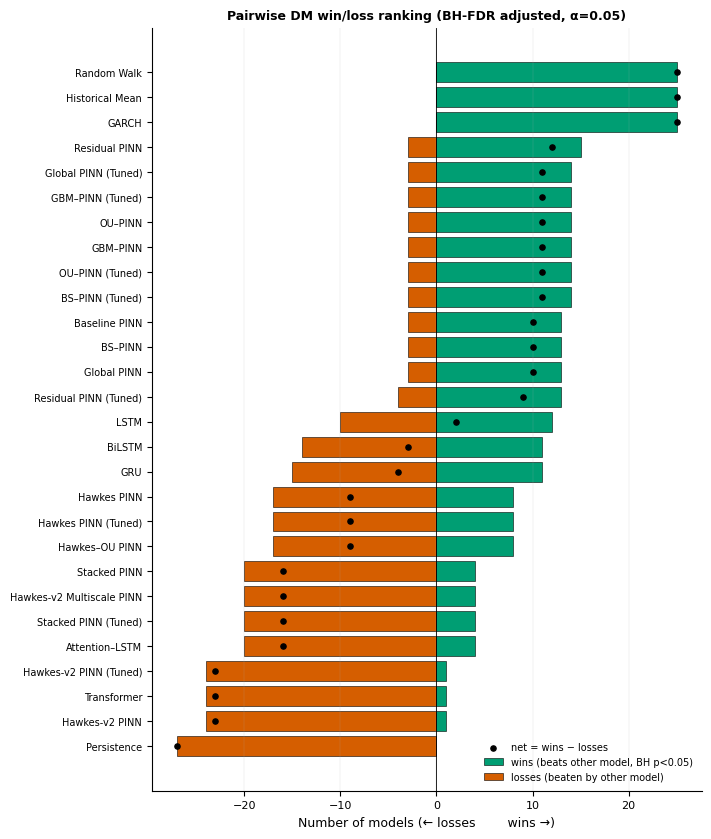

✓ Saved results/final_dm/dm_win_loss.{pdf,png}


In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 9, "axes.titlesize": 10,
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.bbox": "tight",
}

with mpl.rc_context(_pub_rc):
    df = win_df.sort_values("net", ascending=True)
    y  = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(7.0, 0.26 * len(df) + 1.0),
                           constrained_layout=True)

    ax.barh(y,  df["wins"].values,    color="#009E73", edgecolor="black",
            lw=0.4, label="wins (beats other model, BH p<0.05)")
    ax.barh(y, -df["losses"].values,  color="#D55E00", edgecolor="black",
            lw=0.4, label="losses (beaten by other model)")

    # Net markers
    ax.scatter(df["net"].values, y, color="black", s=14, zorder=5,
               label="net = wins − losses")

    ax.axvline(0, color="black", lw=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([pretty(m) for m in df.index.tolist()], fontsize=7)
    ax.set_xlabel("Number of models (← losses        wins →)")
    ax.set_title("Pairwise DM win/loss ranking (BH-FDR adjusted, α=0.05)",
                 fontsize=9, fontweight="bold")
    ax.grid(axis="x", lw=0.3, alpha=0.4)
    ax.legend(loc="lower right", frameon=False, fontsize=7)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

    fig.savefig(out_dir / "dm_win_loss.pdf", facecolor="white")
    fig.savefig(out_dir / "dm_win_loss.png", dpi=300, facecolor="white")
    display(fig); plt.close(fig)
print(f"Saved {out_dir}/dm_win_loss.{{pdf,png}}")


In [ ]:
NEURAL_MODELS    = ["lstm", "gru", "bilstm", "attention_lstm", "transformer"]
CLASSICAL_MODELS = ["random_walk", "historical_mean", "garch", "persistence"]
TIER12_MODELS    = CLASSICAL_MODELS + NEURAL_MODELS

rows = []
for m in TIER12_MODELS:
    if m not in preds_store:
        continue
    p   = preds_store[m]
    a   = ACTUAL
    T   = len(a)
    rmse = float(np.sqrt(np.mean((a - p) ** 2)))

    da, n_correct, n_eff = directional_accuracy(p, a, drop_ties=True)
    binom_p = float(stats.binomtest(n_correct, n_eff, p=0.5,
                                    alternative="two-sided").pvalue) if n_eff else float("nan")

    if m == "random_walk" or "random_walk" not in preds_store:
        dm_s, dm_p = float("nan"), float("nan")
    else:
        dm_s, dm_p = dm_test(p, preds_store["random_walk"], a)

    rows.append({
        "model":          m,
        "T":              T,
        "rmse":           round(rmse, 5),
        "da":             round(da, 4) if not np.isnan(da) else float("nan"),
        "n_eff":          n_eff,
        "binom_p_da50":   round(binom_p, 4) if not np.isnan(binom_p) else float("nan"),
        "dm_vs_rw":       round(dm_s, 3) if not np.isnan(dm_s) else float("nan"),
        "p_dm_vs_rw":     round(dm_p, 4) if not np.isnan(dm_p) else float("nan"),
    })

tier12_df = pd.DataFrame(rows).set_index("model")
print("\n=== Section 6.2 baseline tier - DM vs random_walk and DA=0.5 binomial ===")
print(tier12_df.to_string())
tier12_df.to_csv(out_dir / "tier12_dm_binomial.csv")
print(f"\nSaved {out_dir}/tier12_dm_binomial.csv")
print("Interpretation: dm_vs_rw > 0  =>  random_walk has lower MSE (row model is worse).")
print("                binom_p_da50 < 0.05  =>  DA differs significantly from a coin flip.")



=== Section 6.2 baseline tier - DM vs random_walk and DA=0.5 binomial ===
                    T     rmse      da  n_eff  binom_p_da50  dm_vs_rw  p_dm_vs_rw
model                                                                            
random_walk      1149  0.01107     NaN      0           NaN       NaN         NaN
historical_mean  1149  0.01106  0.5448   1149        0.0026    -0.895      0.3709
garch            1149  0.01106  0.5448   1149        0.0026    -0.552      0.5808
persistence      1149  0.01616  0.4848   1149        0.3158    10.128      0.0000
lstm             1149  0.01154  0.4795   1149        0.1747     4.201      0.0000
gru              1149  0.01176  0.4761   1149        0.1111     5.889      0.0000
bilstm           1149  0.01174  0.4822   1149        0.2380     5.628      0.0000
attention_lstm   1149  0.01388  0.5117   1149        0.4431     6.628      0.0000
transformer      1149  0.01508  0.5274   1149        0.0673    11.974      0.0000

✓ Saved results/final_

In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 9, "axes.titlesize": 10,
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.bbox": "tight",
}

with mpl.rc_context(_pub_rc):
    df = tier12_df.copy()
    is_neural = df.index.isin(NEURAL_MODELS)
    colors = np.where(is_neural, "#0072B2", "#999999")

    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), constrained_layout=True)


    axA = axes[0]
    order_a = df["rmse"].sort_values().index
    yA = np.arange(len(order_a))
    rmse_v = df.loc[order_a, "rmse"].values
    cA = np.where(df.loc[order_a].index.isin(NEURAL_MODELS), "#0072B2", "#999999")
    axA.barh(yA, rmse_v, color=cA, edgecolor="black", lw=0.4)
    for k, m in enumerate(order_a):
        p = df.loc[m, "p_dm_vs_rw"]
        if not np.isnan(p) and p < 0.05:
            axA.text(rmse_v[k] * 1.01, yA[k], "★",
                     va="center", ha="left", fontsize=9, color="crimson")
    axA.set_yticks(yA)
    axA.set_yticklabels([pretty(m) for m in order_a], fontsize=7)
    axA.set_xlabel("RMSE")
    axA.set_title("(A) RMSE  ·  ★ = DM p<0.05 vs Random Walk",
                  fontsize=9, fontweight="bold", loc="left")
    axA.grid(axis="x", lw=0.3, alpha=0.4)
    for s in ("top", "right"):
        axA.spines[s].set_visible(False)


    axB = axes[1]
    order_b = df["da"].sort_values(ascending=False).index
    yB = np.arange(len(order_b))
    da_v = df.loc[order_b, "da"].values
    cB = np.where(df.loc[order_b].index.isin(NEURAL_MODELS), "#0072B2", "#999999")
    axB.barh(yB, da_v - 0.5, left=0.5, color=cB, edgecolor="black", lw=0.4)
    axB.axvline(0.5, color="black", lw=0.7, ls="--", label="coin flip (DA=0.5)")
    for k, m in enumerate(order_b):
        p = df.loc[m, "binom_p_da50"]
        if not np.isnan(p) and p < 0.05:
            x = da_v[k] + (0.005 if da_v[k] >= 0.5 else -0.005)
            ha = "left" if da_v[k] >= 0.5 else "right"
            axB.text(x, yB[k], "★", va="center", ha=ha,
                     fontsize=9, color="crimson")
    axB.set_yticks(yB)
    axB.set_yticklabels([pretty(m) for m in order_b], fontsize=7)
    axB.set_xlabel("Directional accuracy")
    axB.set_xlim(0.40, 0.60)
    axB.set_title("(B) DA  ·  ★ = binomial p<0.05 vs DA=0.5",
                  fontsize=9, fontweight="bold", loc="left")
    axB.grid(axis="x", lw=0.3, alpha=0.4)
    axB.legend(loc="lower right", frameon=False, fontsize=7)
    for s in ("top", "right"):
        axB.spines[s].set_visible(False)


    handles = [mpl.patches.Patch(color="#0072B2", label="Neural (Tier 2)"),
               mpl.patches.Patch(color="#999999", label="Classical (Tier 1)")]
    axB.legend(
        handles=[mpl.patches.Patch(color="#0072B2", label="Neural (Tier 2)"),
                 mpl.patches.Patch(color="#999999", label="Classical (Tier 1)"),
                 plt.Line2D([0], [0], color="black", lw=0.7, ls="--", label="coin flip (DA=0.5)")],
        loc="lower right", frameon=True, framealpha=0.85, edgecolor="0.85",
        fontsize=7,
    )
    fig.suptitle("Baseline tier — RMSE & DA significance",
                 fontsize=10, fontweight="bold")

    fig.savefig(out_dir / "tier12_rmse_da.pdf", facecolor="white")
    fig.savefig(out_dir / "tier12_rmse_da.png", dpi=300, facecolor="white")
    display(fig); plt.close(fig)
print(f"Saved {out_dir}/tier12_rmse_da.{{pdf,png}}")

In [ ]:
import shutil
_drive_dm = Path("/content/drive/MyDrive/finn_results/final_dm")
if Path("/content/drive/MyDrive").exists():
    _drive_dm.mkdir(parents=True, exist_ok=True)
    shutil.copytree(out_dir, _drive_dm, dirs_exist_ok=True)
    print(f"Mirrored to Drive -> {_drive_dm}")
else:
    print("Drive not mounted — skip mirror")


✓ Mirrored to Drive -> /content/drive/MyDrive/finn_results/final_dm
